Sales & Demand Forecasting for Businesses

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings("ignore")

In [2]:
# GENERATE SYNTHETIC SALES DATASET
def generate_sales_data():
    np.random.seed(42)
    dates = pd.date_range(start="2021-01-01", end="2023-12-31", freq="W")
    n = len(dates)

    trend = np.linspace(200, 500, n)
    seasonality = 80 * np.sin(2 * np.pi * np.arange(n) / 52)
    noise = np.random.normal(0, 30, n)
    promo_effect = np.where(np.arange(n) % 13 == 0, 100, 0)

    sales = trend + seasonality + noise + promo_effect
    sales = np.maximum(sales, 50)

    df = pd.DataFrame({
        "date": dates,
        "sales": sales,
        "promo": (np.arange(n) % 13 == 0).astype(int),
        "temperature": 20 + 15 * np.sin(2 * np.pi * np.arange(n) / 52) + np.random.normal(0, 3, n),
        "holiday": np.random.choice([0, 1], size=n, p=[0.92, 0.08])
    })
    return df

In [3]:
# FEATURE ENGINEERING
def engineer_features(df):
    df = df.copy()
    df["week"] = df["date"].dt.isocalendar().week.astype(int)
    df["month"] = df["date"].dt.month
    df["quarter"] = df["date"].dt.quarter
    df["year"] = df["date"].dt.year
    df["week_of_year"] = df["date"].dt.isocalendar().week.astype(int)
    df["sin_week"] = np.sin(2 * np.pi * df["week_of_year"] / 52)
    df["cos_week"] = np.cos(2 * np.pi * df["week_of_year"] / 52)

    # Lag features
    for lag in [1, 2, 4, 8, 52]:
        df[f"sales_lag_{lag}"] = df["sales"].shift(lag)

    # Rolling statistics
    for window in [4, 8, 12]:
        df[f"rolling_mean_{window}"] = df["sales"].shift(1).rolling(window).mean()
        df[f"rolling_std_{window}"] = df["sales"].shift(1).rolling(window).std()

    df.dropna(inplace=True)
    return df

In [4]:
# TRAIN MODELS
def train_models(df):
    feature_cols = [c for c in df.columns if c not in ["date", "sales"]]
    X = df[feature_cols]
    y = df["sales"]

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

    models = {
        "Linear Regression": LinearRegression(),
        "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
        "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, random_state=42)
    }

    results = {}
    for name, model in models.items():
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
        results[name] = {
            "model": model,
            "predictions": preds,
            "y_test": y_test,
            "MAE": mean_absolute_error(y_test, preds),
            "RMSE": np.sqrt(mean_squared_error(y_test, preds)),
            "R2": r2_score(y_test, preds)
        }
        print(f"\n {name}")
        print(f"   MAE  : {results[name]['MAE']:.2f}")
        print(f"   RMSE : {results[name]['RMSE']:.2f}")
        print(f"   R²   : {results[name]['R2']:.4f}")

    return results, X_test, y_test, X_train, y_train

In [7]:
# 4. VISUALIZATIONS
def plot_results(df, results, X_test, y_test):
    fig, axes = plt.subplots(3, 2, figsize=(18, 16))
    fig.suptitle("Sales & Demand Forecasting Dashboard", 
                 fontsize=16, fontweight="bold", y=1.01)
    colors = {"Linear Regression": "#e74c3c", "Random Forest": "#2ecc71", "Gradient Boosting": "#3498db"}

    # --- Plot 1: Full Sales History ---
    ax = axes[0, 0]
    ax.plot(df["date"], df["sales"], color="#2c3e50", linewidth=1.2, label="Actual Sales")
    ax.set_title("Historical Sales Trend", fontsize=13, fontweight="bold")
    ax.set_xlabel("Date"); ax.set_ylabel("Sales Units")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.legend(); ax.grid(alpha=0.3)

    # --- Plot 2: Model Predictions vs Actual ---
    ax = axes[0, 1]
    test_dates = df.loc[y_test.index, "date"]
    ax.plot(test_dates.values, y_test.values, color="black", linewidth=1.5, label="Actual", zorder=5)
    for name, res in results.items():
        ax.plot(test_dates.values, res["predictions"], linestyle="--", 
                color=colors[name], linewidth=1.2, label=name, alpha=0.85)
    ax.set_title("Model Predictions vs Actual (Test Set)", fontsize=13, fontweight="bold")
    ax.set_xlabel("Date"); ax.set_ylabel("Sales Units")
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

    # --- Plot 3: Model Comparison Bar ---
    ax = axes[1, 0]
    names = list(results.keys())
    maes = [results[n]["MAE"] for n in names]
    bars = ax.bar(names, maes, color=[colors[n] for n in names], edgecolor="black", linewidth=0.8)
    for bar, val in zip(bars, maes):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f"{val:.1f}", 
                ha="center", fontweight="bold", fontsize=10)
    ax.set_title("Model Comparison – MAE (Lower is Better)", fontsize=13, fontweight="bold")
    ax.set_ylabel("Mean Absolute Error"); ax.grid(axis="y", alpha=0.3)

    # --- Plot 4: R² Score Comparison ---
    ax = axes[1, 1]
    r2s = [results[n]["R2"] for n in names]
    bars = ax.bar(names, r2s, color=[colors[n] for n in names], edgecolor="black", linewidth=0.8)
    for bar, val in zip(bars, r2s):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, f"{val:.3f}", 
                ha="center", fontweight="bold", fontsize=10)
    ax.set_ylim(0, 1.1)
    ax.set_title("Model R² Score (Higher is Better)", fontsize=13, fontweight="bold")
    ax.set_ylabel("R² Score"); ax.grid(axis="y", alpha=0.3)

    # --- Plot 5: Monthly Average Sales ---
    ax = axes[2, 0]
    monthly = df.groupby("month")["sales"].mean()
    month_names = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
    ax.bar(month_names, monthly.values, color=sns.color_palette("Blues_d", 12), edgecolor="black")
    ax.set_title("Average Monthly Sales Pattern", fontsize=13, fontweight="bold")
    ax.set_xlabel("Month"); ax.set_ylabel("Avg Sales")
    ax.grid(axis="y", alpha=0.3)

    # --- Plot 6: 12-Week Future Forecast (Best Model) ---
    ax = axes[2, 1]
    best_name = max(results, key=lambda n: results[n]["R2"])
    best_model = results[best_name]["model"]
    feature_cols = [c for c in df.columns if c not in ["date", "sales"]]
    last_row = df[feature_cols].iloc[[-1]]
    future_preds = []
    last_sales = df["sales"].iloc[-1]
    future_dates = pd.date_range(df["date"].iloc[-1] + pd.Timedelta(weeks=1), periods=12, freq="W")

    for i in range(12):
        pred = best_model.predict(last_row)[0] + np.random.normal(0, 15)
        future_preds.append(pred)

    recent = df.tail(30)
    ax.plot(recent["date"].values, recent["sales"].values, color="#2c3e50", linewidth=1.5, label="Historical")
    ax.plot(future_dates, future_preds, color="#e67e22", linewidth=2, linestyle="--", marker="o", 
            markersize=5, label="12-Week Forecast")
    ax.fill_between(future_dates, 
                    [p - 40 for p in future_preds], 
                    [p + 40 for p in future_preds], 
                    alpha=0.2, color="#e67e22", label="Confidence Band")
    ax.set_title(f"12-Week Future Forecast ({best_name})", fontsize=13, fontweight="bold")
    ax.set_xlabel("Date"); ax.set_ylabel("Predicted Sales")
    ax.legend(fontsize=9); ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig("sales_forecast_dashboard.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("\nDashboard saved as 'sales_forecast_dashboard.png'")



Task 1: Sales Forecasting

[1/4] Generating sales data...
[2/4] Engineering features...
[3/4] Training models...


 Linear Regression
   MAE  : 25.48
   RMSE : 33.67
   R²   : 0.7265

 Random Forest
   MAE  : 31.55
   RMSE : 47.73
   R²   : 0.4503

 Gradient Boosting
   MAE  : 34.58
   RMSE : 47.46
   R²   : 0.4566

[4/4] Generating visualizations...


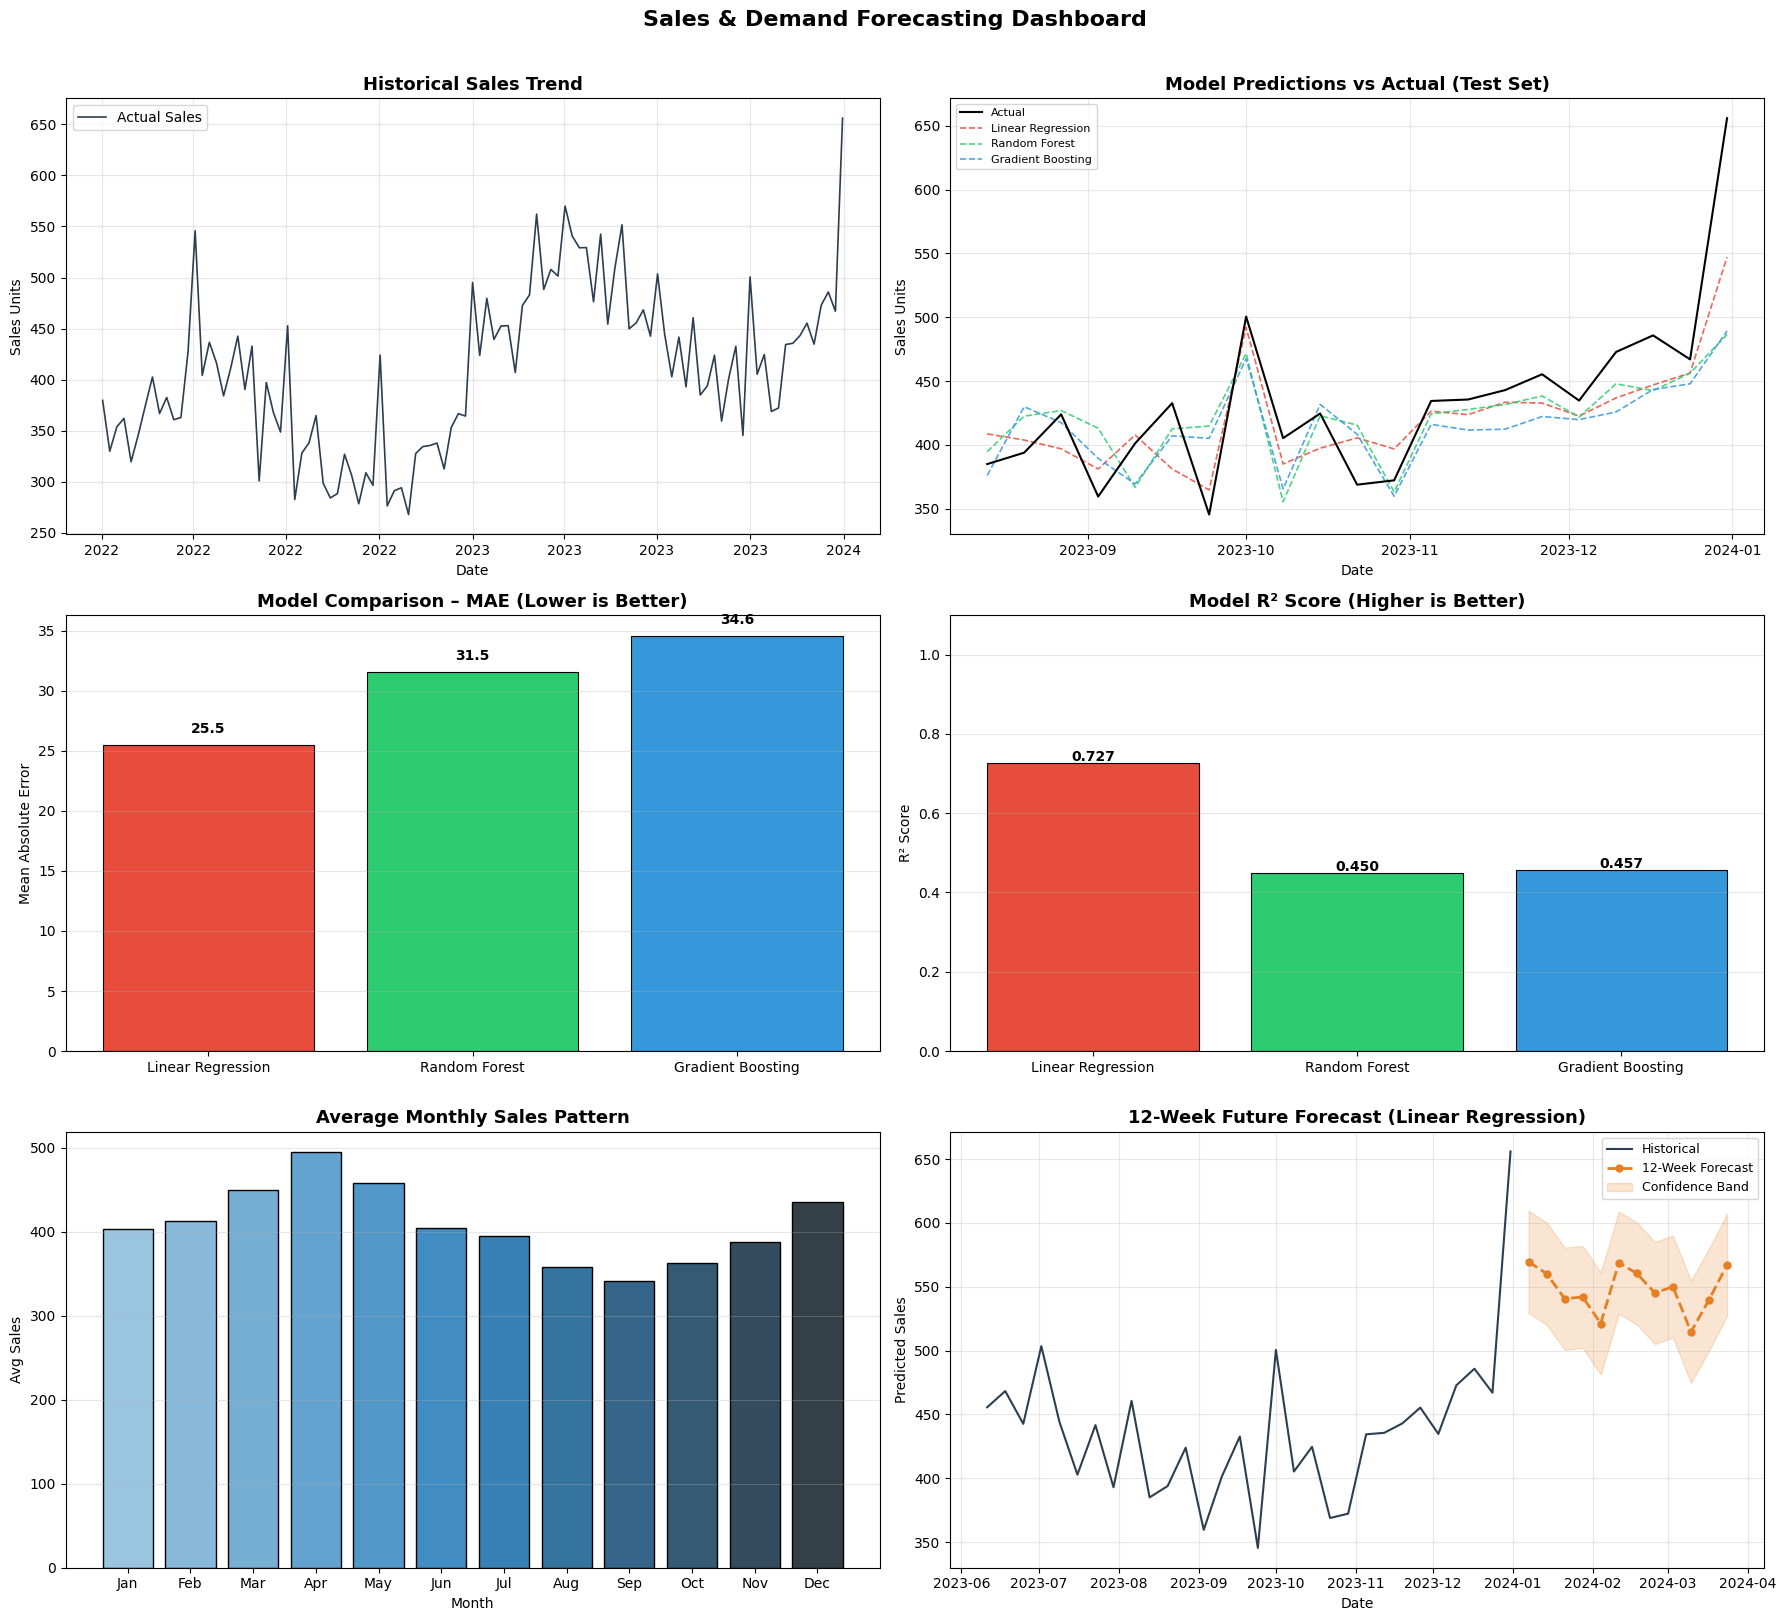


Dashboard saved as 'sales_forecast_dashboard.png'

Best Model: Linear Regression (R² = 0.7265)


In [8]:
# MAIN
if __name__ == "__main__":
    print("=" * 55)
    print("Task 1: Sales Forecasting")
    print("=" * 55)

    print("\n[1/4] Generating sales data...")
    df_raw = generate_sales_data()

    print("[2/4] Engineering features...")
    df = engineer_features(df_raw)

    print("[3/4] Training models...\n")
    results, X_test, y_test, X_train, y_train = train_models(df)

    print("\n[4/4] Generating visualizations...")
    plot_results(df, results, X_test, y_test)

    best = max(results, key=lambda n: results[n]["R2"])
    print(f"\nBest Model: {best} (R² = {results[best]['R2']:.4f})")